# Switching linear dynamical systems

A switching linear dynamical system (SLDS) combines a discrete regime $z_t$ with a continuous latent state $x_t$. Each regime selects a different linear dynamical system, while a Markov chain determines when the model switches between regimes.

This tutorial defines the complete model, generates synthetic data with observed control inputs, filters the mixed latent state with a Rao–Blackwellized particle filter, and makes predictive rollouts.

## Model setup

We introduce the model in generative order, beginning with the measured data.

### 1. Observation model

Let $y_t \in \mathbb{R}^{d_y}$ be the observation, $x_t \in \mathbb{R}^{d_x}$ the continuous latent state, $z_t \in \{0,\ldots,K-1\}$ the discrete regime, and $u_t \in \mathbb{R}^{d_u}$ a known control input. We treat $u_t$ as observed rather than latent.

$$
y_t \mid x_t,z_t,u_t
\sim
\mathcal{N}\left(
C_{z_t}x_t + D_{z_t}u_t + d_{z_t},
R_{z_t}
\right).
$$

The active regime selects the observation matrix $C_{z_t}$, optional observation-control matrix $D_{z_t}$, observation bias $d_{z_t}$, and observation-noise covariance $R_{z_t}$.

In this tutorial, the observed control has no direct effect on the observation once $x_t$ is given. We explicitly set

$$
D_{z_t}=0 \qquad \text{for every regime } z_t.
$$

Hence, the observation model used below is

$$
y_t \mid x_t,z_t
\sim
\mathcal{N}\left(
C_{z_t}x_t+d_{z_t},
R_{z_t}
\right).
$$

The control $u_t$ therefore affects $y_t$ only indirectly, through its effect on the latent dynamics via $B_{z_t}u_t$.

### 2. Continuous latent dynamics

Using the convention that $z_t$ labels the dynamics active on the interval from $t$ to $t+1$, the continuous state evolves according to

$$
x_{t+1}
=
A_{z_t}x_t + B_{z_t}u_t + b_{z_t} + \epsilon_t,
\qquad
\epsilon_t \sim \mathcal{N}(0,Q_{z_t}).
$$

Equivalently,

$$
x_{t+1}\mid x_t,z_t,u_t
\sim
\mathcal{N}\left(
A_{z_t}x_t+B_{z_t}u_t+b_{z_t},
Q_{z_t}
\right).
$$

Here $A_{z_t}$ controls the autonomous dynamics and $B_{z_t}$ describes the effect of the observed input. Both can differ across regimes.

The implementation below uses the equivalent destination-state indexing common in SLDS code: $z_{t+1}$ selects the parameters that generate $x_{t+1}$. This is only a one-step relabeling of the regime sequence.

### 3. Switching dynamics

In a conventional SLDS, the regime sequence is a first-order Markov chain:

$$
z_{t+1}\mid z_t
\sim
\operatorname{Categorical}\left(P_{z_t,:}\right),
$$

or, componentwise,

$$
p(z_{t+1}=k\mid z_t=j)=P_{jk},
\qquad
\sum_{k=0}^{K-1}P_{jk}=1.
$$



### Initial conditions

The joint latent process needs initial distributions for both latent variables:

$$
z_0 \sim \operatorname{Categorical}(\pi_0),
$$

$$
x_0\mid z_0=k
\sim
\mathcal{N}(m_{0,k},\Sigma_{0,k}).
$$

Together, these equations define the generative model for $(z_{0:T},x_{0:T},y_{0:T})$ conditional on the observed controls $u_{0:T}$.

## SLDS in Dynestyx

Dynestyx stores the joint latent state as $[z_t,x_t]$: the first scalar is the discrete regime and the remaining entries form the continuous state. The model has these three main components that we use throughout:

- MixedStateDistribution for the initial joint state;
- SwitchingLinearGaussianStateEvolution for the Markov switch and regime-specific continuous dynamics;
- SwitchingLinearGaussianObservation for the observation model.

For inference we use a Rao–Blackwellized particle filter (RBPF). It samples particles over the discrete regime history while analytically marginalizing the conditionally linear-Gaussian state with Kalman updates. 

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
import optax
from numpyro.infer import Predictive, SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoDelta
from numpyro.infer.initialization import init_to_value

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, DynamicalModel, Filter, flatten_draws
from dynestyx.inference.filter_configs import RBPFConfig
from dynestyx.models import (
    MixedStateDistribution,
    SwitchingLinearGaussianObservation,
    SwitchingLinearGaussianStateEvolution,
)

num_regimes = 2
state_dim = 2
observation_dim = 2
control_dim = 1
num_timesteps = 100
train_timesteps = 75

times_full = jnp.arange(float(num_timesteps))
obs_times = times_full[:train_timesteps]
predict_times = times_full[train_timesteps:]

## Observed control inputs

We assume controls u(t) are values supplied to the model. For simulation we create a smooth signal with occasional pulses. During filtering and prediction we pass the corresponding control times and values to the model; dynestyx conditions on these values rather than inferring them.

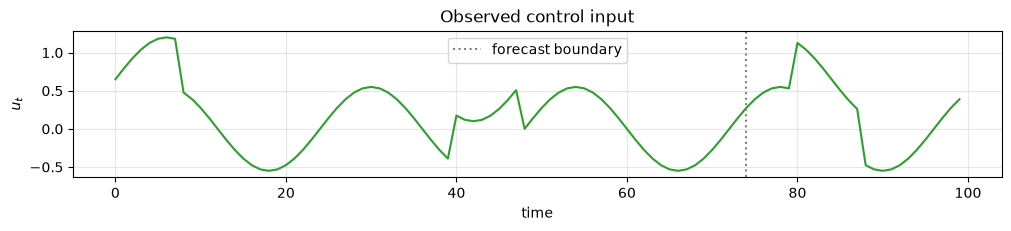

In [2]:
## Generate u(t)

## sin wave control
smooth_control = 0.55 * jnp.sin(2.0 * jnp.pi * times_full / 24.0) 
## binary pulse with 0.65 mag
control_pulses = 0.65 * ((times_full % 40.0) < 8.0) 
ctrl_values = (smooth_control + control_pulses)[:, None]
ctrl_times = times_full

fig, ax = plt.subplots(figsize=(10, 2.2), constrained_layout=True)
ax.plot(ctrl_times, ctrl_values[:, 0], color="C2")
ax.axvline(float(obs_times[-1]), color="0.5", linestyle=":", label="forecast boundary")
ax.set(xlabel="time", ylabel=r"$u_t$", title="Observed control input")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Initialize synthetic SLDS parameters

The transition matrix $P$ is sticky: both regimes usually persist, but switching remains possible. Each regime has its own state matrix $A_k$, control matrix $B_k$, bias $b_k$, and process covariance $Q_k$. We observe both state coordinates through a two-dimensional observation model. The observation covariance is correlated, which makes the coordinate-wise masking behavior explicit: masking one coordinate must also remove its cross-covariance with the other coordinate.

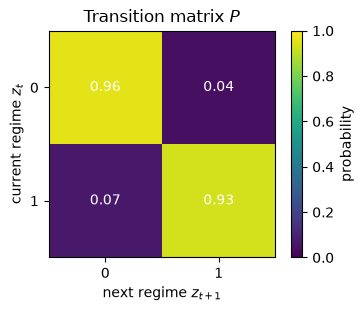

In [3]:
## Assume two regimes here, K=2
transition_matrix = jnp.array([[0.96, 0.04], [0.07, 0.93]])
initial_probs = jnp.array([0.85, 0.15])

## autonomous dynamics matrix
A = jnp.array(
    [
        [[0.94, 0.18], [-0.12, 0.88]],
        [[0.62, -0.26], [0.18, 0.70]],
    ]
)
## input matrix
B = jnp.array(
    [
        [[0.16], [0.02]],
        [[-0.10], [0.14]],
    ]
)
## bias term
b = jnp.array([[0.00, 0.00], [0.55, -0.25]]) 
Q = jnp.tile(0.07**2 * jnp.eye(state_dim), (num_regimes, 1, 1))

## observation model
C = jnp.tile(jnp.eye(observation_dim)[None, :, :], (num_regimes, 1, 1))
d = jnp.zeros((num_regimes, observation_dim))
observation_cov = jnp.array(
    [
        [0.13**2, 0.35 * 0.13 * 0.18],
        [0.35 * 0.13 * 0.18, 0.18**2],
    ]
)
R = jnp.tile(observation_cov[None, :, :], (num_regimes, 1, 1))

initial_mean = jnp.zeros((num_regimes, state_dim))
initial_cov = jnp.tile(0.40 * jnp.eye(state_dim), (num_regimes, 1, 1))

fig, ax = plt.subplots(figsize=(4, 3), constrained_layout=True)
image = ax.imshow(transition_matrix, vmin=0.0, vmax=1.0, cmap="viridis")
for row in range(num_regimes):
    for column in range(num_regimes):
        ax.text(column, row, f"{transition_matrix[row, column]:.2f}", ha="center", va="center", color="white")
ax.set(
    xlabel=r"next regime $z_{t+1}$",
    ylabel=r"current regime $z_t$",
    xticks=range(num_regimes),
    yticks=range(num_regimes),
    title="Transition matrix $P$",
)
fig.colorbar(image, ax=ax, label="probability")
plt.show()

## Define the dynestyx model

MixedStateDistribution implements the two initial-condition equations. SwitchingLinearGaussianStateEvolution combines the categorical transition with the regime-specific linear-Gaussian state dynamics. The observation wrapper selects $C_{z_t}$, $d_{z_t}$, and $R_{z_t}$.

The same model function accepts observation, prediction, and control trajectories, so we can reuse it for simulation, filtering, and forecasting.

In [4]:
## Define dynestyx SLDS model using DynamicalModel

def slds_model(
    obs_times=None,
    obs_values=None,
    predict_times=None,
    ctrl_times=None,
    ctrl_values=None,
    **kwargs,
):
    state_evolution = SwitchingLinearGaussianStateEvolution(
        transition_matrix=transition_matrix,
        A=A,
        B=B,
        bias=b,
        cov=Q,
    )
    observation_model = SwitchingLinearGaussianObservation(H=C, R=R, bias=d)
    dynamics = DynamicalModel(
        control_dim=control_dim,
        initial_condition=MixedStateDistribution(
            categorical_probs=initial_probs,
            continuous_locs=initial_mean,
            continuous_covs=initial_cov,
        ),
        state_evolution=state_evolution,
        observation_model=observation_model,
    )
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
        **kwargs,
    )

## Generate synthetic data

We use DiscreteTimeSimulator to generate samples by drawing from the initial joint state, emitting $y_0$, and applying the switching transition one step at a time. 

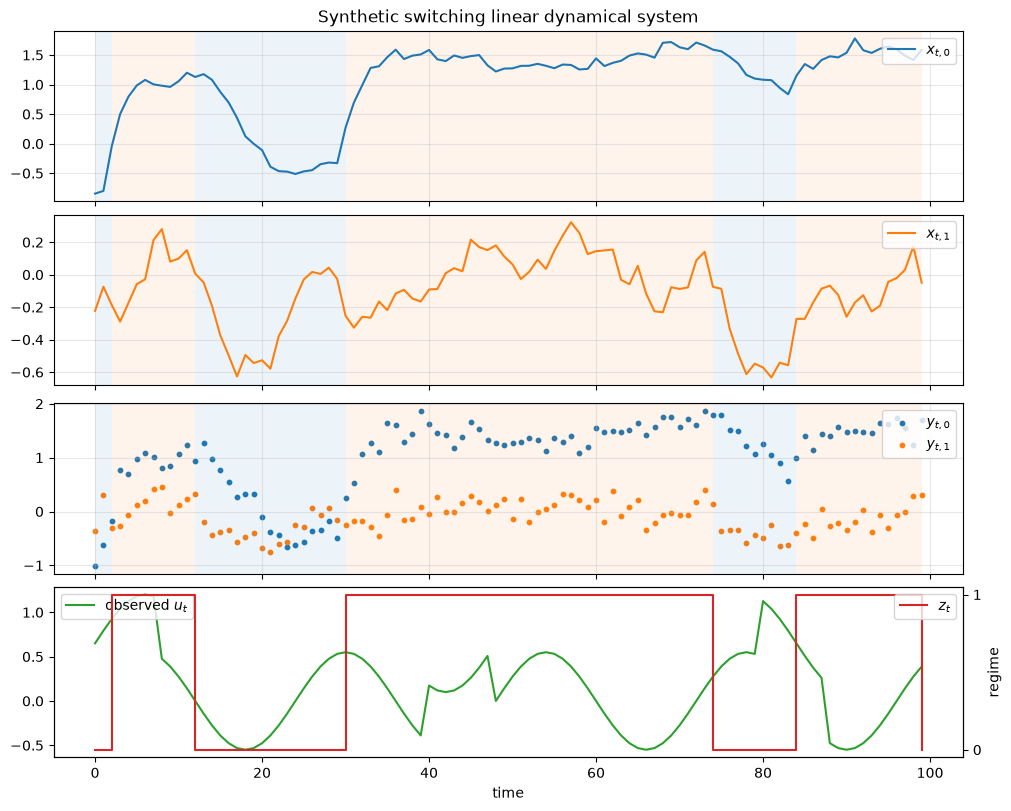

In [5]:
with DiscreteTimeSimulator():
    synthetic = Predictive(
        slds_model,
        num_samples=1,
        exclude_deterministic=False,
    )(
        jr.PRNGKey(0),
        predict_times=times_full,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )

times = synthetic["f_times"][0, 0]
joint_states = synthetic["f_states"][0, 0]
true_regimes = joint_states[:, 0].astype(int)
true_states = joint_states[:, 1:]
observations = synthetic["f_observations"][0, 0]

obs_values = observations[:train_timesteps]
states_train = true_states[:train_timesteps]
regimes_train = true_regimes[:train_timesteps]


def shade_regimes(ax, plot_times, regimes, alpha=0.08):
    for t0, t1, z in zip(plot_times[:-1], plot_times[1:], regimes[:-1]):
        ax.axvspan(float(t0), float(t1), color=f"C{int(z)}", alpha=alpha, lw=0)


fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True, constrained_layout=True)
for index in range(state_dim):
    axes[index].plot(times, true_states[:, index], color=f"C{index}", label=rf"$x_{{t,{index}}}$")
    shade_regimes(axes[index], times, true_regimes)
    axes[index].legend(loc="upper right")
    axes[index].grid(True, alpha=0.3)

for index in range(observation_dim):
    axes[2].scatter(
        times,
        observations[:, index],
        s=10,
        color=f"C{index}",
        label=rf"$y_{{t,{index}}}$",
    )
shade_regimes(axes[2], times, true_regimes)
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)

axes[3].plot(times, ctrl_values[:, 0], color="C2", label=r"observed $u_t$")
regime_axis = axes[3].twinx()
regime_axis.step(times, true_regimes, where="post", color="C3", label=r"$z_t$")
regime_axis.set_yticks(range(num_regimes))
regime_axis.set_ylabel("regime")
axes[3].legend(loc="upper left")
regime_axis.legend(loc="upper right")
axes[3].set_xlabel("time")
axes[0].set_title("Synthetic switching linear dynamical system")
plt.show()